In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("ggplot")

In [2]:
X, y = make_classification(

    n_samples=3000,

    n_features=10,

    n_informative=8,

    n_redundant=2,

    n_classes=2,

    random_state=42

)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [5]:
k = 9

In [6]:
euclidean = KNeighborsClassifier(

    n_neighbors=k,

    metric="minkowski",

    p=2

)

euclidean.fit(X_train,y_train)

euclidean_pred = euclidean.predict(X_test)

In [7]:
manhattan = KNeighborsClassifier(

    n_neighbors=k,

    metric="minkowski",

    p=1

)

manhattan.fit(X_train,y_train)

manhattan_pred = manhattan.predict(X_test)

In [23]:
minkowski = KNeighborsClassifier(

    n_neighbors=k,

    metric="minkowski",

    p=4

)

minkowski.fit(X_train,y_train)

minkowski_pred = minkowski.predict(X_test)

In [24]:
euclidean_acc = accuracy_score(
    y_test,
    euclidean_pred
)

manhattan_acc = accuracy_score(
    y_test,
    manhattan_pred
)

minkowski_acc = accuracy_score(
    y_test,
    minkowski_pred
)

print("Euclidean :",euclidean_acc)

print("Manhattan :",manhattan_acc)

print("Minkowski :",minkowski_acc)

Euclidean : 0.9066666666666666
Manhattan : 0.905
Minkowski : 0.91


In [25]:
comparison = pd.DataFrame({

    "Distance Metric":[

        "Euclidean",

        "Manhattan",

        "Minkowski (p=3)"

    ],

    "Accuracy":[

        euclidean_acc,

        manhattan_acc,

        minkowski_acc

    ]

})

comparison

,Distance Metric,Accuracy
0,Euclidean,0.906667
1,Manhattan,0.905000
2,Minkowski (p=3),0.910000


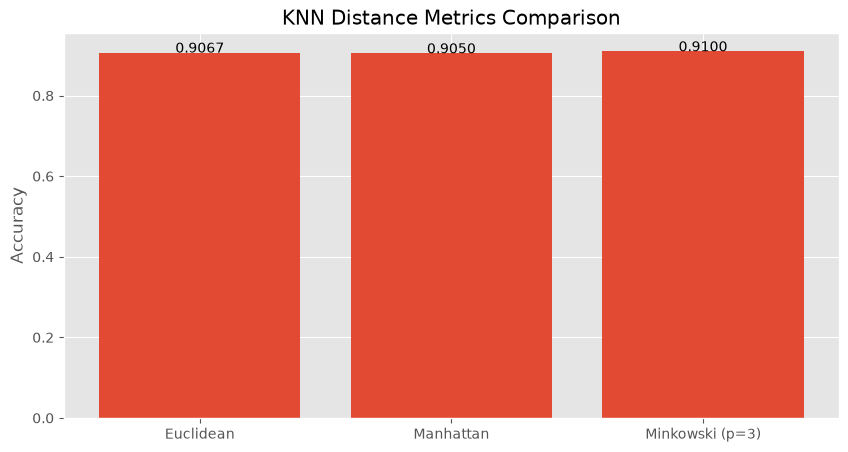

In [26]:
plt.figure(figsize=(10,5))

bars = plt.bar(

    comparison["Distance Metric"],

    comparison["Accuracy"]

)

plt.title(
    "KNN Distance Metrics Comparison"
)

plt.ylabel(
    "Accuracy"
)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height,

        f"{height:.4f}",

        ha="center"

    )

plt.show()

In [22]:
best_metric = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_metric)

Distance Metric    Euclidean
Accuracy            0.906667
Name: 0, dtype: object


In [27]:
summary = pd.DataFrame({

    "Metric":[

        "Dataset Size",

        "Features",

        "K Value",

        "Best Distance Metric",

        "Best Accuracy"

    ],

    "Value":[

        len(X),

        X.shape[1],

        k,

        best_metric["Distance Metric"],

        round(best_metric["Accuracy"],4)

    ]

})

summary

,Metric,Value
0,Dataset Size,3000
1,Features,10
2,K Value,9
3,Best Distance Metric,Euclidean
4,Best Accuracy,0.9067
